# PASTIS-R Filter for FarSLIP Preparation

Discards patches dominated by Background / Meadow so that FarSLIP
feature extraction focuses on informative crop patches.

**Filter rule**: keep a patch only if the combined pixel coverage of
a configurable set of *target classes* is ≥ `MIN_COVERAGE` of all
valid (non-void) pixels.

## Key parameters
| Parameter | Default | Meaning |
|-----------|---------|--------|
| `TARGET_CLASSES` | all crops except Meadow | class indices that count toward coverage |
| `MIN_COVERAGE` | 0.50 | minimum fraction of valid pixels in target classes |
| `IGNORE_INDEX` | 255 | void pixel value (excluded from denominator) |

## 0. Setup

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import shutil
import matplotlib.pyplot as plt
from pathlib import Path
from getpass import getpass


# Option A: upload from your local machine via Colab file picker

_IN_COLAB = False
shared_folder_path = ''
try:
    from google.colab import drive
    drive.mount('/content/drive')
    shared_folder_path = '/content/drive/MyDrive/Integrador/'
    _IN_COLAB = True
except ImportError:
    pass

# Clone repo
_repo_dir = '/content/agrosat-copilot'
_branch = 'user/iavila/pastis-preparation-for-farslip'
_repo = 'github.com/ArthurZizumbo/agrosat-copilot.git'

import subprocess
r = subprocess.run(['git', 'pull', '--rebase', 'origin', _branch],
                   capture_output=True, text=True, cwd='/content/agrosat-copilot')
print(r.stdout, r.stderr)

if not Path(_repo_dir, 'pyproject.toml').is_file():
    _rc = os.system(f'git clone --branch {_branch} --depth 1 https://{_repo} {_repo_dir}')
    if _rc != 0:
        _tok = getpass('GitHub token: ')
        os.system(f'git clone --branch {_branch} --depth 1 https://{_tok}@{_repo} {_repo_dir}')

# Add to path
sys.path.insert(0, _repo_dir)
os.chdir(_repo_dir)
print('repo:', Path.cwd())
print('pastis_filter exists:', Path('ml/data/pastis_filter.py').exists())

PASTIS_ROOT = Path((shared_folder_path + 'data/PASTIS-R') if shared_folder_path
                   else 'data/PASTIS-R')
print('PASTIS_ROOT:', PASTIS_ROOT, '| exists:', PASTIS_ROOT.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.
 From https://github.com/ArthurZizumbo/agrosat-copilot
 * branch            user/iavila/pastis-preparation-for-farslip -> FETCH_HEAD

repo: /content/agrosat-copilot
pastis_filter exists: True
PASTIS_ROOT: /content/drive/MyDrive/Integrador/data/PASTIS-R | exists: True


In [9]:
import subprocess

if _IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', '-q', 'install',
                    'structlog', 'dvc', 'dvc-gs'], check=False)

# Authenticate with GCS (same as before)
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

Authenticated


## 1. Configure filter parameters

In [3]:
from ml.data.pastis_filter import (
    PastisFilter, FilteredPASTISDataset,
    PASTIS_CLASS_NAMES, ALL_CROP_CLASSES, HCAT_GROUPS, CLASSES_OF_INTEREST
)

# ── Key parameters (reconfigurable) ──────────────────────────────────────────

# Minimum fraction of valid pixels that must belong to TARGET_CLASSES
MIN_COVERAGE = 0.50

# Ignore index (void pixels excluded from denominator)
IGNORE_INDEX = 255

# TARGET_CLASSES: which classes count toward the coverage threshold.
# Default: all crop classes EXCEPT Background (0), Meadow (1), Void (19)
# → only keep patches where ≥50% of valid pixels are actual crops.
#
# You can narrow this further, e.g. only cereals + oilseeds:
#   TARGET_CLASSES = HCAT_GROUPS['CEREALS'] + HCAT_GROUPS['OILSEEDS']
#
# Or only the 6 HCAT groups of interest:
#   TARGET_CLASSES = [c for g in HCAT_GROUPS.values() for c in g if c != 1]
TARGET_CLASSES = CLASSES_OF_INTEREST

print(f'MIN_COVERAGE   : {MIN_COVERAGE:.0%}')
print(f'IGNORE_INDEX   : {IGNORE_INDEX}')
print(f'TARGET_CLASSES : {sorted(TARGET_CLASSES)}')
print('Named classes  :')
for ci in sorted(TARGET_CLASSES):
    print(f'  [{ci:2d}] {PASTIS_CLASS_NAMES.get(ci, "?")}' )

MIN_COVERAGE   : 50%
IGNORE_INDEX   : 255
TARGET_CLASSES : [2, 3, 8]
Named classes  :
  [ 2] Soft winter wheat
  [ 3] Corn
  [ 8] Grapevine


## 2. EDA — coverage distribution before choosing threshold

Scan all training patches and plot coverage distribution to validate
that `MIN_COVERAGE=0.50` is a sensible cutoff.

Computing coverage stats (all folds) …

Patches scanned : 2433
Mean coverage   : 0.183
Median coverage : 0.155
P25 / P75       : 0.031 / 0.292
% above 30%     : 23.7%
% above 50%     : 4.8%
% above 70%     : 0.2%


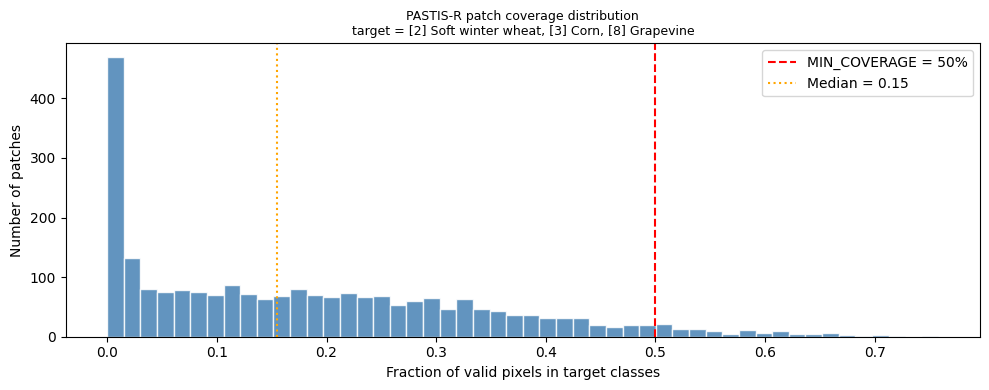

Patches kept with current threshold: 116


In [4]:
filt = PastisFilter(
    pastis_root    = PASTIS_ROOT,
    target_classes = TARGET_CLASSES,
    min_coverage   = MIN_COVERAGE,
    ignore_index   = IGNORE_INDEX,
)

print('Computing coverage stats (all folds) …')
stats = filt.coverage_stats(folds=[1, 2, 3, 4, 5])

print(f"\nPatches scanned : {stats['n_patches']}")
print(f"Mean coverage   : {stats['mean']:.3f}")
print(f"Median coverage : {stats['median']:.3f}")
print(f"P25 / P75       : {stats['p25']:.3f} / {stats['p75']:.3f}")
print(f"% above 30%     : {stats['pct_above_30']:.1%}")
print(f"% above 50%     : {stats['pct_above_50']:.1%}")
print(f"% above 70%     : {stats['pct_above_70']:.1%}")

# Plot distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(stats['coverages'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(MIN_COVERAGE, color='red', linestyle='--', linewidth=1.5,
           label=f'MIN_COVERAGE = {MIN_COVERAGE:.0%}')
ax.axvline(stats['median'], color='orange', linestyle=':', linewidth=1.5,
           label=f'Median = {stats["median"]:.2f}')
ax.set_xlabel('Fraction of valid pixels in target classes')
ax.set_ylabel('Number of patches')
_class_labels = [f'[{c}] {PASTIS_CLASS_NAMES[c]}' for c in sorted(CLASSES_OF_INTEREST)]
_title_classes = ', '.join(_class_labels)
ax.set_title(
    f'PASTIS-R patch coverage distribution\n'
    f'target = {_title_classes}',
    fontsize=9
)
ax.legend()
plt.tight_layout()
plt.savefig('coverage_distribution.png', dpi=150)
plt.show()
print('Patches kept with current threshold:',
      int(stats['pct_above_50'] * stats['n_patches']))

## 3. Apply filter and build DataLoaders

In [5]:
from torch.utils.data import DataLoader

# ── Option A: use FilteredPASTISDataset (drop-in replacement) ────────────────
train_ds = FilteredPASTISDataset(
    root           = PASTIS_ROOT,
    folds          = [1, 2, 3],
    target_classes = TARGET_CLASSES,
    min_coverage   = MIN_COVERAGE,
    ignore_index   = IGNORE_INDEX,
    # PASTISSegmentationDataset kwargs:
    collapse_time  = None,
    n_timesteps    = 10,
    target         = 'semantic18',
)
val_ds = FilteredPASTISDataset(
    root           = PASTIS_ROOT,
    folds          = [4],
    target_classes = TARGET_CLASSES,
    min_coverage   = MIN_COVERAGE,
    ignore_index   = IGNORE_INDEX,
    collapse_time  = None,
    n_timesteps    = 10,
    target         = 'semantic18',
)
test_ds = FilteredPASTISDataset(
    root           = PASTIS_ROOT,
    folds          = [5],
    target_classes = TARGET_CLASSES,
    min_coverage   = MIN_COVERAGE,
    ignore_index   = IGNORE_INDEX,
    collapse_time  = None,
    n_timesteps    = 10,
    target         = 'semantic18',
)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,
                          num_workers=1, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False,
                          num_workers=1, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=4, shuffle=False,
                          num_workers=1, persistent_workers=True)

print(f'Train: {len(train_ds):4d} patches  ({train_ds.n_kept}/{train_ds.n_total})')
print(f'Val  : {len(val_ds):4d} patches  ({val_ds.n_kept}/{val_ds.n_total})')
print(f'Test : {len(test_ds):4d} patches  ({test_ds.n_kept}/{test_ds.n_total})')

2026-06-06 19:46:32 [info     ] pastis_seg_dataset_init        collapse_time=None folds=(1, 2, 3) has_norm_stats=True n_patches=1455 num_classes=18 target=semantic18
FilteredPASTISDataset: folds=[1, 2, 3] | target_classes=[2, 3, 8] | min_coverage=50% | kept=74/1455 (5.1%)
2026-06-06 19:46:34 [info     ] pastis_seg_dataset_init        collapse_time=None folds=(4,) has_norm_stats=True n_patches=482 num_classes=18 target=semantic18
FilteredPASTISDataset: folds=[4] | target_classes=[2, 3, 8] | min_coverage=50% | kept=25/482 (5.2%)
2026-06-06 19:46:36 [info     ] pastis_seg_dataset_init        collapse_time=None folds=(5,) has_norm_stats=True n_patches=496 num_classes=18 target=semantic18
FilteredPASTISDataset: folds=[5] | target_classes=[2, 3, 8] | min_coverage=50% | kept=17/496 (3.4%)
Train:   74 patches  (74/1455)
Val  :   25 patches  (25/482)
Test :   17 patches  (17/496)


## 4. Reconfiguration examples

Swap `TARGET_CLASSES` to target specific HCAT groups or individual crops.

In [6]:
# ── Example 1: only cereals + oilseeds (FarSLIP for grain/oil crops) ─────────
cereals_oilseeds = HCAT_GROUPS['CEREALS'] + HCAT_GROUPS['OILSEEDS']
filt_co = PastisFilter(PASTIS_ROOT, target_classes=cereals_oilseeds,
                       min_coverage=0.50, ignore_index=IGNORE_INDEX)
kept_co = filt_co.filter_folds([1, 2, 3, 4, 5])
print(f'Cereals+Oilseeds only: {len(kept_co)} patches kept')

# ── Example 2: minority classes only (FarSLIP for rare crops) ────────────────
minority = HCAT_GROUPS['LEGUMES'] + HCAT_GROUPS['ROOT_CROPS']
filt_min = PastisFilter(PASTIS_ROOT, target_classes=minority,
                        min_coverage=0.30,   # lower threshold — minority classes are rare
                        ignore_index=IGNORE_INDEX)
kept_min = filt_min.filter_folds([1, 2, 3, 4, 5])
print(f'Legumes+Root crops  : {len(kept_min)} patches kept')

# ── Example 3: permanent woody crops (vineyards, orchards) ───────────────────
woody = HCAT_GROUPS['PERMANENT_WOODY']
filt_w = PastisFilter(PASTIS_ROOT, target_classes=woody,
                      min_coverage=0.20,   # woody crops rarely dominate a full 128px patch
                      ignore_index=IGNORE_INDEX)
kept_w = filt_w.filter_folds([1, 2, 3, 4, 5])
print(f'Permanent woody     : {len(kept_w)} patches kept')

# ── Summary table ─────────────────────────────────────────────────────────────
import polars as pl
summary = pl.DataFrame({
    'configuration':   ['All crops (default)', 'Cereals+Oilseeds', 'Legumes+Root crops', 'Woody crops'],
    'target_classes':  [str(sorted(ALL_CROP_CLASSES)), str(sorted(cereals_oilseeds)),
                        str(sorted(minority)), str(sorted(woody))],
    'min_coverage':    [0.50, 0.50, 0.30, 0.20],
    'patches_kept':    [filt.total_scanned, len(kept_co), len(kept_min), len(kept_w)],
})
display(summary)

Cereals+Oilseeds only: 309 patches kept
Legumes+Root crops  : 1 patches kept
Permanent woody     : 181 patches kept


configuration,target_classes,min_coverage,patches_kept
str,str,f64,i64
"""All crops (default)""","""[2, 3, 4, 5, 6, 7, 8, 9, 10, 1…",0.5,0
"""Cereals+Oilseeds""","""[2, 3, 4, 5, 6, 7, 10, 11, 14,…",0.5,309
"""Legumes+Root crops""","""[9, 13, 14, 15]""",0.3,1
"""Woody crops""","""[8, 16]""",0.2,181


## 5. Export filtered patch IDs for FarSLIP

In [7]:
import json

# Get kept IDs per fold for FarSLIP
filt_full = PastisFilter(
    pastis_root    = PASTIS_ROOT,
    target_classes = TARGET_CLASSES,
    min_coverage   = MIN_COVERAGE,
    ignore_index   = IGNORE_INDEX,
)

farslip_splits = {}
for fold, split in [([ 1, 2, 3], 'train'), ([4], 'val'), ([5], 'test')]:
    kept = filt_full.filter_folds(fold)
    farslip_splits[split] = kept
    print(f'{split:5s}: {len(kept)} patches')

# Save as JSON for FarSLIP pipeline
output_path = Path('data/pastis_farslip_filtered_splits.json')
output_path.parent.mkdir(parents=True, exist_ok=True)
with open(output_path, 'w') as f:
    json.dump({
        'metadata': {
            'target_classes': sorted(TARGET_CLASSES),
            'target_class_names': {str(c): PASTIS_CLASS_NAMES[c] for c in sorted(TARGET_CLASSES)},
            'min_coverage': MIN_COVERAGE,
            'ignore_index': IGNORE_INDEX,
        },
        'splits': farslip_splits,
    }, f, indent=2)
print(f'Saved: {output_path}')

# Also save as parquet for easy loading in FarSLIP notebooks
import polars as pl
rows = []
for split, ids in farslip_splits.items():
    for pid in ids:
        rows.append({'split': split, 'patch_id': pid})
df = pl.DataFrame(rows)
parquet_path = Path('data/pastis_farslip_filtered_splits.parquet')
df.write_parquet(parquet_path)
print(f'Saved: {parquet_path}')
display(df.group_by('split').len().sort('split'))

train: 74 patches
val  : 25 patches
test : 17 patches
Saved: data/pastis_farslip_filtered_splits.json
Saved: data/pastis_farslip_filtered_splits.parquet


split,len
str,u32
"""test""",17
"""train""",74
"""val""",25


In [ ]:
# Copy to Drive as the primary storage (like other data artifacts)
import shutil
drive_data_path = Path(shared_folder_path + 'data/pastis_farslip_filtered_splits.parquet')
shutil.copy2(parquet_path, drive_data_path)
print(f'Saved to Drive: {drive_data_path}')

# add to DVC and push (matches how the repo handles data files)
r = subprocess.run(['dvc', 'add', 'data/pastis_farslip_filtered_splits.parquet'],
                   capture_output=True, text=True, cwd='/content/agrosat-copilot')
print(r.stdout, r.stderr)

r = subprocess.run(['dvc', 'push'],
                   capture_output=True, text=True, cwd='/content/agrosat-copilot')
print(r.stdout, r.stderr)

# commit the .dvc pointer file to git
r = subprocess.run(
    ['git', 'add', 'data/pastis_farslip_filtered_splits.parquet.dvc', '.gitignore'],
    capture_output=True, text=True, cwd='/content/agrosat-copilot'
)
r = subprocess.run(
    ['git', 'commit', '-m', 'data: add filtered PASTIS-R splits for FarSLIP (DVC)'],
    capture_output=True, text=True, cwd='/content/agrosat-copilot'
)
r = subprocess.run(
    ['git', 'push', 'origin', 'user/iavila/pastis-preparation-for-farslip'],
    capture_output=True, text=True, cwd='/content/agrosat-copilot'
)
print('Done')

Saved to Drive: /content/drive/MyDrive/Integrador/data/pastis_farslip_filtered_splits.parquet
 
1 file pushed
 
Done
